In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests


In [ ]:
def calcular_taxa_100k(obitos, populacao):
    return ((obitos / populacao) * 100000).round(2)

In [ ]:
codigo_estado = {
    "11": "RO", "12": "AC", "13": "AM", "14": "RR", "15": "PA",
    "16": "AP", "17": "TO", "21": "MA", "22": "PI", "23": "CE",
    "24": "RN", "25": "PB", "26": "PE", "27": "AL", "28": "SE",
    "29": "BA", "31": "MG", "32": "ES", "33": "RJ", "35": "SP",
    "41": "PR", "42": "SC", "43": "RS", "50": "MS", "51": "MT",
    "52": "GO", "53": "DF"
}


In [ ]:
url = "https://servicodados.ibge.gov.br/api/v3/agregados/6579/periodos/2015|2016|2017|2018|2019|2020|2021|2022/variaveis/9324?localidades=N3[all]"

response = requests.get(url)
dados = response.json()
print(response.status_code)

200


In [ ]:
registros = []


for serie in dados[0]["resultados"][0]["series"]:
    estado = codigo_estado[serie["localidade"]["id"]]
    for ano, populacao in serie["serie"].items():
        registros.append({
            "ESTADO": estado,
            "ANO": int(ano),
            "POPULACAO": int(populacao)
        })

populacao_df = pd.DataFrame(registros)
print(populacao_df.shape)
print(populacao_df.head())


(189, 3)
  ESTADO   ANO  POPULACAO
0     RO  2015    1768204
1     RO  2016    1787279
2     RO  2017    1805788
3     RO  2018    1757589
4     RO  2019    1777225


In [ ]:
df_tabnet = pd.read_csv("obitos_tabnet_2015_2021.csv").dropna()
print(df_tabnet.head(5))
print(df_tabnet.shape)

        ESTADO   2015   2016   2017   2018   2019   2020   2021
0  11 Rondônia   63.0   54.0   62.0   42.0   43.0   54.0   54.0
1      12 Acre   19.0   23.0   34.0   35.0   32.0   27.0   28.0
2  13 Amazonas  115.0  116.0  115.0  127.0  118.0   85.0  135.0
3   14 Roraima   29.0   25.0   27.0   53.0   33.0   35.0   20.0
4      15 Pará  261.0  294.0  310.0  323.0  232.0  192.0  207.0
(27, 8)


In [ ]:
df_tabnet["ESTADO"] = df_tabnet["ESTADO"].str[:2].map(codigo_estado)
print(df_tabnet["ESTADO"].head())


0    RO
1    AC
2    AM
3    RR
4    PA
Name: ESTADO, dtype: object


In [ ]:
obitos_agrupados = df_tabnet.melt(
    id_vars="ESTADO",
    var_name="ANO",
    value_name="OBITOS"
)

obitos_agrupados["ANO"] = obitos_agrupados["ANO"].astype(int)
obitos_agrupados["OBITOS"] = obitos_agrupados["OBITOS"].astype(int)

print(obitos_agrupados.shape)
print(obitos_agrupados.head())

(189, 3)
  ESTADO   ANO  OBITOS
0     RO  2015      63
1     AC  2015      19
2     AM  2015     115
3     RR  2015      29
4     PA  2015     261


In [ ]:
tabela_unificada = pd.merge(obitos_agrupados, populacao_df, on=["ESTADO", "ANO"], how="inner")

In [ ]:
tabela_unificada["TAXA_POR_100K"] = calcular_taxa_100k(
    tabela_unificada["OBITOS"],
    tabela_unificada["POPULACAO"]
)

In [ ]:
evolucao_brasil = (
    tabela_unificada.groupby("ANO")[["OBITOS", "POPULACAO"]]
    .sum()
    .reset_index()
) 
print(evolucao_brasil)

    ANO  OBITOS  POPULACAO
0  2015    4616  204450049
1  2016    4635  206081432
2  2017    4928  207660929
3  2018    4512  208494900
4  2019    3728  210147125
5  2020    3822  211755692
6  2021    3844  213317639


In [ ]:
evolucao_brasil["TAXA_BRASIL"] = calcular_taxa_100k(
    evolucao_brasil["OBITOS"],
    evolucao_brasil["POPULACAO"]
)

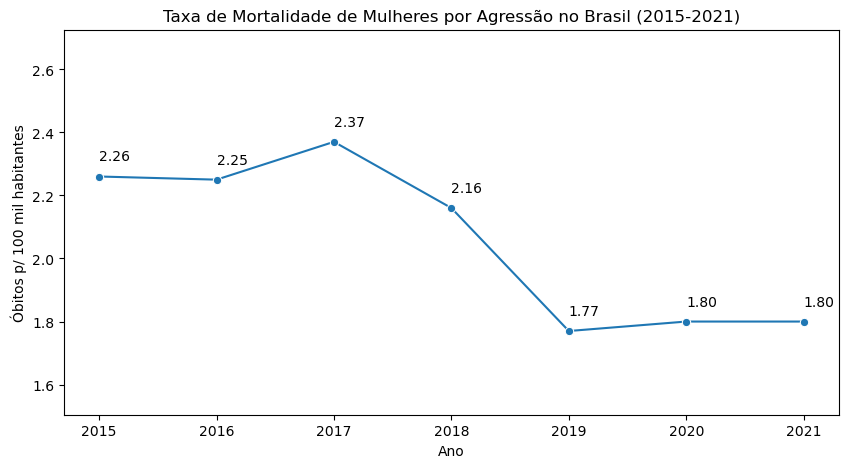

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
grafico_linha = sns.lineplot(
    data=evolucao_brasil, 
    x="ANO",
    y="TAXA_BRASIL",
    marker = "o",
    ax=ax,
)

grafico_linha.set(
    title="Taxa de Mortalidade de Mulheres por Agressão no Brasil (2015-2021)",
    xlabel="Ano", 
    ylabel="Óbitos p/ 100 mil habitantes",
    ylim=(evolucao_brasil["TAXA_BRASIL"].min() * 0.85, evolucao_brasil["TAXA_BRASIL"].max() * 1.15)
)

for indice, linha in evolucao_brasil.iterrows():

    grafico_linha.text(
        x=linha["ANO"],
        y=linha["TAXA_BRASIL"]
        + 0.05,
        s=f'{linha["TAXA_BRASIL"]:.2f}',
    )

fig.savefig(
    "taxa_mortalidade_brasil.png",
    dpi=300,
    bbox_inches="tight",
)
    
plt.show()

In [ ]:
ranking_estado_historico = (
    tabela_unificada.groupby("ESTADO")[["OBITOS", "POPULACAO"]]
    .sum()
    .reset_index()
)

ranking_estado_historico["TAXA_ESTADO"] = calcular_taxa_100k(
    ranking_estado_historico["OBITOS"],
    ranking_estado_historico["POPULACAO"]
)

ranking_estado_historico = ranking_estado_historico.sort_values(
    by="TAXA_ESTADO", ascending=False
)

ranking_estado_historico

,ESTADO,OBITOS,POPULACAO,TAXA_ESTADO
21,RR,222,4008753,5.54
5,CE,2194,63523992,3.45
0,AC,198,6002365,3.30
13,PA,1819,59398696,3.06
20,RO,372,12507823,2.97
7,ES,819,28083562,2.92
8,GO,1408,48344952,2.91
4,BA,3026,105425946,2.87
2,AM,811,28706534,2.83
19,RN,690,24505107,2.82


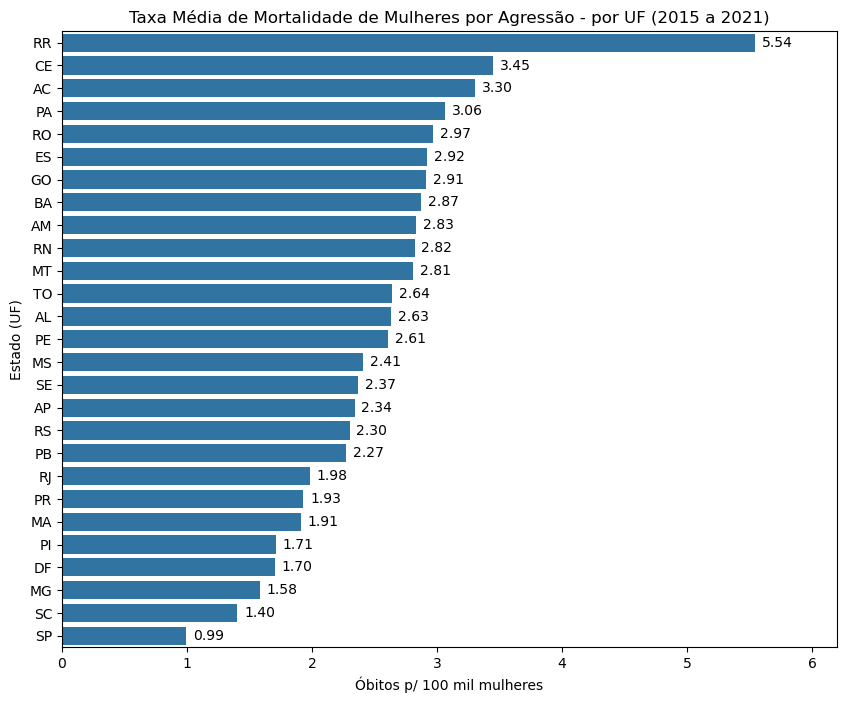

In [ ]:
fig, ax = plt.subplots(figsize=(10,8))

grafico_barras = sns.barplot(
    data=ranking_estado_historico,
    x="TAXA_ESTADO",
    y="ESTADO",
    ax=ax
)

grafico_barras.set(
    title="Taxa Média de Mortalidade de Mulheres por Agressão - por UF (2015 a 2021)",
    xlabel="Óbitos p/ 100 mil mulheres",
    ylabel="Estado (UF)",
    xlim=(0, 6.2)
)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=5
)

fig.savefig("variacao percentual", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
df_pivot = tabela_unificada.pivot(index="ESTADO", columns="ANO", values="TAXA_POR_100K")
df_pivot["VARIACAO_PERCENTUAL"] = (
    ((df_pivot[2021] - df_pivot[2015]) / df_pivot[2015]) * 100
)
df_pivot["TENDENCIA"] = df_pivot["VARIACAO_PERCENTUAL"].apply(lambda x: "Piora (Aumento)" if x > 0  else "Melhora (Queda)")
tabela_variacao = df_pivot.sort_values(by="VARIACAO_PERCENTUAL", ascending=False)



In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

grafico_variacao = sns.barplot(
    data=tabela_variacao,
    x="VARIACAO_PERCENTUAL",
    y="ESTADO",
    hue="TENDENCIA",
    ax=ax,
    palette={
        "Piora (Aumento)": "#d62728",
        "Melhora (Queda)": "#2ca02c"
    }
)

grafico_variacao.set(
    title="Variação Percentual da Taxa de Mortalidade por Agressão (2015 vs 2021)",
    xlabel="Variação (%) na Taxa por 100 mil mulheres",
    ylabel="Estado (UF)",
    xlim=(-60,60)
)

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

plt.legend(title="Tendência do Período", loc="lower right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

fig.savefig(
    "variacao_mortalidade_uf_2015_2021.png", dpi=300, bbox_inches="tight"
)

plt.show()


IndentationError: unexpected indent (1190935870.py, line 3)